# French Property Intelligence
## 01 — Data Audit & Exploratory Data Analysis

### Objective

This notebook establishes a reliable understanding of the French real-estate transaction dataset before any modeling decisions are made.

The first stage focuses on:
- dataset structure and provenance,
- schema and data types,
- unit of observation,
- geographic and temporal coverage,
- candidate target definition,
- missing and potentially invalid values,
- duplicates and transaction structure,
- potential data leakage,
- and variables requiring special attention for privacy or production use.

Only after the data audit is validated will the notebook proceed to focused exploratory data analysis.

In [1]:
import sys

print("Notebook Python:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Notebook Python:
c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\.venv\Scripts\python.exe

Python version:
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [2]:
# Imports and configuration

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Reproducibility
RANDOM_STATE = 42

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"

TRANSACTIONS_PATH = DATA_RAW_DIR / "transactions.npz"
TRANSACTIONS_SAMPLE_PATH = DATA_RAW_DIR / "transactions_sample.csv"

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"PyArrow: {pa.__version__}")
print(f"\nProject root: {PROJECT_ROOT}")
print(f"Raw data directory: {DATA_RAW_DIR}")

Python: 3.13.9
NumPy: 2.5.3
Pandas: 3.0.6
PyArrow: 25.0.1

Project root: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence
Raw data directory: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\data\raw


## 1. Data sources and file inventory

The raw data directory contains the main real-estate transaction dataset together with several contextual datasets related to the French property market.

The initial analysis focuses on the transaction data. Contextual datasets are retained in their original form and may later be evaluated as additional features through controlled experiments.

Before loading the transaction dataset, we first inspect the available source files, their formats, and their sizes.

In [3]:
# Inventory raw data files

raw_files = pd.DataFrame(
    [
        {
            "file_name": path.name,
            "extension": path.suffix,
            "size_mb": path.stat().st_size / (1024 ** 2),
        }
        for path in DATA_RAW_DIR.iterdir()
        if path.is_file()
    ]
).sort_values("size_mb", ascending=False)

raw_files.reset_index(drop=True, inplace=True)

raw_files

,file_name,extension,size_mb
0,transactions.npz,.npz,457.98
1,foyers_fiscaux.csv,.csv,17.49
2,loyers.csv,.csv,5.67
3,parc_immobilier.csv,.csv,1.47
4,transactions_sample.csv,.csv,0.02
5,flux_nouveaux_emprunts.csv,.csv,0.00
6,indice_reference_loyers.csv,.csv,0.00
7,taux_interet.csv,.csv,0.00
8,taux_endettement.csv,.csv,0.00


### Transaction file format

The main transaction file is named `transactions.npz`. However, preliminary file inspection showed that its binary signature begins with `PAR1`, identifying the physical storage format as **Apache Parquet**, not a NumPy `.npz` archive.

The original filename is preserved in `data/raw/` to maintain the source data unchanged. The file is therefore read using PyArrow's Parquet interface rather than NumPy.

In [4]:
# Inspect transaction dataset metadata without loading the full dataset

parquet_file = pq.ParquetFile(TRANSACTIONS_PATH)

transaction_metadata = {
    "rows": parquet_file.metadata.num_rows,
    "columns": parquet_file.metadata.num_columns,
    "row_groups": parquet_file.metadata.num_row_groups,
}

transaction_metadata

{'rows': 9141573, 'columns': 20, 'row_groups': 9}

In [5]:
# Inspect the logical schema

transaction_schema = parquet_file.schema_arrow

schema_df = pd.DataFrame({
    "column": transaction_schema.names,
    "dtype": [str(field.type) for field in transaction_schema],
})

schema_df

,column,dtype
0,id_transaction,int32
1,date_transaction,timestamp[ns]
2,prix,double
3,id_ville,int32
4,code_postal,int32
5,vefa,bool
6,n_pieces,int32
7,surface_habitable,int32
8,latitude,double
9,longitude,double


### Transaction sample

A small CSV sample is provided alongside the full transaction dataset. It is used here to inspect example records and understand the semantics of the variables before loading the full dataset into memory.

The sample is not assumed to be statistically representative of the complete dataset.

In [6]:
# Load the provided transaction sample

transactions_sample = pd.read_csv(TRANSACTIONS_SAMPLE_PATH)

print(f"Sample shape: {transactions_sample.shape}")
print("\nColumns:")
print(transactions_sample.columns.tolist())

transactions_sample.head(10)

Sample shape: (100, 20)

Columns:
['id_transaction', 'date_transaction', 'prix', 'departement', 'id_ville', 'ville', 'code_postal', 'adresse', 'type_batiment', 'vefa', 'n_pieces', 'surface_habitable', 'id_parcelle_cadastre', 'latitude', 'longitude', 'surface_dependances', 'surface_locaux_industriels', 'surface_terrains_agricoles', 'surface_terrains_sols', 'surface_terrains_nature']


,id_transaction,date_transaction,prix,departement,id_ville,ville,code_postal,adresse,type_batiment,vefa,n_pieces,surface_habitable,id_parcelle_cadastre,latitude,longitude,surface_dependances,surface_locaux_industriels,surface_terrains_agricoles,surface_terrains_sols,surface_terrains_nature
0,10160888,2015-07-22,"222,500.00",63,247,MUROL,63790,5148 COMBE,Maison,False,4,123,63247000ZO0165,45.57,2.95,{},{},{},{2387},{}
1,10319766,2024-06-18,"218,640.00",73,15,LES ALLUES,73550,45 RUE DU GRAND COEUR,Appartement,False,1,23,73015000AB0347,45.40,6.57,{0},{},{},{},{}
2,11545562,2020-07-23,"254,950.00",77,316,MORET-LOING-ET-ORVANNE,77250,1 RUE DE LA CROIX BLANCHE,Maison,False,6,124,773161700B0305,48.33,2.78,{},{},{},{815},{}
3,13891173,2022-10-03,"380,000.00",94,81,VITRY-SUR-SEINE,94400,11 VOIE VICTOR MASSE,Maison,False,3,93,94081000AK0189,48.80,2.38,{},{},{},{208},{}
4,11794772,2018-07-12,"258,000.00",77,284,MEAUX,77100,14 RUE PIERRE BONTEMPS,Maison,False,5,96,77284000AW0090,48.95,2.89,{},{},{},{},{}
5,12400323,2023-09-27,"141,000.00",83,137,TOULON,83100,112 RUE DE L'HOPITAL FONT PRE,Appartement,False,2,37,83137000AX0634,43.13,5.97,{0},{},{},{},{}
6,9795965,2019-10-03,"39,990.00",63,80,CHAMPEIX,63320,3 PTR PTE RUE DE BEAUREGARD,Maison,False,5,84,63080000AB0147,45.59,3.13,{},{},{},{},{}
7,13512916,2017-01-04,"58,000.00",85,49,CHAMPAGNE-LES-MARAIS,85450,5 RUE DES PORTES SEVIGNES,Maison,False,4,127,85049000AH0116,46.38,-1.13,{},{},{},{363},{}
8,395925,2020-08-27,"66,500.00",2,64,BELLEU,2200,10 RUE DE STADTHAGEN,Maison,False,3,62,02064000AB0555,49.37,3.34,{},{},{},{198},{}
9,14721755,2023-03-28,"69,000.00",972,29,SCHOELCHER,97233,5962F RUE CAIUS,Appartement,False,1,30,972290000T0962,14.63,-61.11,{},{},{},{},{}


In [7]:
# Compare the sample schema with the full transaction dataset

sample_columns = set(transactions_sample.columns)
full_columns = set(transaction_schema.names)

print("Columns only in sample:", sorted(sample_columns - full_columns))
print("Columns only in full dataset:", sorted(full_columns - sample_columns))
print("Same column set:", sample_columns == full_columns)

Columns only in sample: []
Columns only in full dataset: []
Same column set: True


### Full dataset loading strategy

The full transaction dataset contains more than 9 million records. Before loading it into memory, its Parquet row-group structure is inspected to determine an appropriate and reproducible loading strategy.


In [8]:
# Inspect Parquet row groups

row_groups = pd.DataFrame(
    [
        {
            "row_group": i,
            "rows": parquet_file.metadata.row_group(i).num_rows,
            "size_mb": parquet_file.metadata.row_group(i).total_byte_size / (1024 ** 2),
        }
        for i in range(parquet_file.metadata.num_row_groups)
    ]
)

row_groups

,row_group,rows,size_mb
0,0,1048576,79.61
1,1,1048576,84.07
2,2,1048576,78.83
3,3,1048576,81.20
4,4,1048576,82.39
5,5,1048576,80.00
6,6,1048576,70.20
7,7,1048576,80.31
8,8,752965,44.57


In [9]:
# Check temporal coverage of the full transaction dataset

dates = parquet_file.read(
    columns=["date_transaction"]
).to_pandas()["date_transaction"]

print(f"Earliest transaction: {dates.min()}")
print(f"Latest transaction:   {dates.max()}")
print(f"Missing dates:        {dates.isna().sum():,}")
print(f"Unique dates:         {dates.nunique():,}")

Earliest transaction: 2014-01-01 00:00:00
Latest transaction:   2024-06-30 00:00:00
Missing dates:        0
Unique dates:         3,757


In [10]:
# Transaction coverage by year

transactions_by_year = (
    dates.dt.year
    .value_counts()
    .sort_index()
    .rename_axis("year")
    .reset_index(name="n_transactions")
)

transactions_by_year

,year,n_transactions
0,2014,642730
1,2015,732433
2,2016,784398
3,2017,904772
4,2018,900658
5,2019,979500
6,2020,944625
7,2021,1091681
8,2022,1034448
9,2023,805028


**Initial temporal audit**

- The dataset covers transactions from **2014-01-01 to 2024-06-30**, with no missing transaction dates.
- Complete calendar years are available from **2014 through 2023**.
- **2024 is a partial year (January–June)** and should therefore not be compared directly with full-year transaction volumes.
- Transaction volume varies substantially over time, with the highest observed annual count in 2021.
- The temporal structure is important for later model validation: a future-oriented valuation system should be evaluated using a chronological split rather than relying only on a random train/test split.
- At this stage, transaction counts describe dataset coverage only; they should not yet be interpreted as a complete measure of French real-estate market activity without further validation of the dataset's coverage and filtering.

In [11]:
# Check temporal coverage of each Parquet row group

row_group_periods = []

for i in range(parquet_file.metadata.num_row_groups):
    rg_dates = (
        parquet_file
        .read_row_group(i, columns=["date_transaction"])
        .to_pandas()["date_transaction"]
    )

    row_group_periods.append({
        "row_group": i,
        "rows": len(rg_dates),
        "date_min": rg_dates.min(),
        "date_max": rg_dates.max(),
    })

row_group_periods = pd.DataFrame(row_group_periods)

row_group_periods

,row_group,rows,date_min,date_max
0,0,1048576,2014-01-02,2024-06-29
1,1,1048576,2014-01-01,2024-06-29
2,2,1048576,2014-01-02,2024-06-29
3,3,1048576,2014-01-02,2024-06-29
4,4,1048576,2014-01-02,2024-06-29
5,5,1048576,2014-01-02,2024-06-30
6,6,1048576,2014-01-02,2024-06-29
7,7,1048576,2014-01-01,2024-06-29
8,8,752965,2014-01-02,2024-06-29


**Row-group structure**

All nine Parquet row groups span almost the complete temporal range of the dataset (2014–2024). The file is therefore not partitioned chronologically.

This makes a single row group suitable for an initial large-scale structural and data-quality audit without restricting the analysis to one historical period. However, row-group membership is not known to be random, so results from one row group are not assumed to represent the full dataset.

In [12]:
# Load one complete row group for the initial structural audit

audit_df = parquet_file.read_row_group(0).to_pandas()

memory_mb = audit_df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Audit subset shape: {audit_df.shape}")
print(f"Memory usage: {memory_mb:,.2f} MB")

audit_df.head()

Audit subset shape: (1048576, 20)
Memory usage: 201.42 MB


,id_transaction,date_transaction,prix,id_ville,code_postal,vefa,n_pieces,surface_habitable,latitude,longitude,departement,ville,adresse,type_batiment,id_parcelle_cadastre,surface_dependances,surface_locaux_industriels,surface_terrains_agricoles,surface_terrains_sols,surface_terrains_nature
0,141653,2014-01-02,"197,000.00",427,1600,False,4,84,45.94,4.77,01,TREVOUX,6346 MTE DES LILAS,Appartement,01427000AD0575,"{0,0}",{},{},{},{}
1,141970,2014-01-02,"157,500.00",451,1440,False,4,103,46.24,5.26,01,VIRIAT,1369 RTE DE STRASBOURG,Maison,01451000ZO0158,{},{},{},"{24,1569}",{}
2,139240,2014-01-02,"112,000.00",365,1290,False,3,78,46.26,4.92,01,SAINT-JEAN-SUR-VEYLE,5174 SAINT JEAN SUR VEYLE,Maison,013650000C0813,{},{},{220},{540},{}
3,146016,2014-01-02,"173,020.00",202,1150,False,4,72,45.90,5.35,01,LAGNIEU,21 GR GRANDE RUE DE BULLIEZ,Maison,012020000F1248,{},{},{},"{336,191}",{}
4,145911,2014-01-03,"88,000.00",283,1100,False,3,104,46.26,5.64,01,OYONNAX,29B RUE DE LA FORGE,Appartement,01283000AN0339,{},{},{},{},{}


## 2. Unit of observation and transaction structure

Before analyzing distributions or defining the modeling target, the dataset's unit of observation must be established.

The variable `id_transaction` suggests that each row may represent a property transaction, but this assumption must be verified. Repeated transaction identifiers could indicate multi-property sales, multiple lots, duplicated records, or another underlying transaction structure.

In [13]:
# Investigate transaction identifier uniqueness in the audit subset

n_rows = len(audit_df)
n_unique_transactions = audit_df["id_transaction"].nunique(dropna=True)
n_missing_transaction_ids = audit_df["id_transaction"].isna().sum()
n_duplicated_transaction_ids = audit_df["id_transaction"].duplicated(keep=False).sum()

print(f"Rows:                         {n_rows:,}")
print(f"Unique transaction IDs:       {n_unique_transactions:,}")
print(f"Missing transaction IDs:      {n_missing_transaction_ids:,}")
print(f"Rows with repeated IDs:        {n_duplicated_transaction_ids:,}")
print(f"ID uniqueness ratio:           {n_unique_transactions / n_rows:.4%}")

Rows:                         1,048,576
Unique transaction IDs:       1,048,574
Missing transaction IDs:      0
Rows with repeated IDs:        3
ID uniqueness ratio:           99.9998%


In [14]:
# Inspect examples of repeated transaction identifiers

repeated_ids = (
    audit_df.loc[
        audit_df["id_transaction"].duplicated(keep=False),
        "id_transaction"
    ]
    .value_counts()
    .head(10)
)

repeated_ids

id_transaction
865708    3
Name: count, dtype: int64

In [15]:
# Inspect the repeated transaction

audit_df.loc[
    audit_df["id_transaction"] == 865708
].sort_values("id_transaction")

,id_transaction,date_transaction,prix,id_ville,code_postal,vefa,n_pieces,surface_habitable,latitude,longitude,departement,ville,adresse,type_batiment,id_parcelle_cadastre,surface_dependances,surface_locaux_industriels,surface_terrains_agricoles,surface_terrains_sols,surface_terrains_nature
597054,865708,2022-01-14,"85,500.00",105,9350,False,3,38,43.13,1.31,09,DAUMAZAN-SUR-ARIZE,27 CAZALERES,Maison,091050000B2066,{},{},{},{721},{}
597055,865708,2022-01-14,"85,500.00",105,9350,False,3,38,43.13,1.31,09,DAUMAZAN-SUR-ARIZE,41 CAZALERES,Maison,091050000B2066,{},{},{},{721},{}
597056,865708,2022-01-14,"85,500.00",105,9350,False,3,38,43.13,1.31,09,DAUMAZAN-SUR-ARIZE,39 CAZALERES,Maison,091050000B2066,{},{},{},{721},{}


In [16]:
# Verify transaction identifier uniqueness across the full dataset

transaction_ids = (
    parquet_file
    .read(columns=["id_transaction"])
    .to_pandas()["id_transaction"]
)

n_total_rows = len(transaction_ids)
n_unique_ids = transaction_ids.nunique(dropna=True)
n_missing_ids = transaction_ids.isna().sum()
n_rows_repeated_ids = transaction_ids.duplicated(keep=False).sum()

print(f"Full dataset rows:             {n_total_rows:,}")
print(f"Unique transaction IDs:        {n_unique_ids:,}")
print(f"Missing transaction IDs:       {n_missing_ids:,}")
print(f"Rows with repeated IDs:         {n_rows_repeated_ids:,}")
print(f"ID uniqueness ratio:            {n_unique_ids / n_total_rows:.4%}")

Full dataset rows:             9,141,573
Unique transaction IDs:        9,141,558
Missing transaction IDs:       0
Rows with repeated IDs:         29
ID uniqueness ratio:            99.9998%


**Unit-of-observation finding**

- The full dataset contains **9,141,573 rows** and **9,141,558 unique transaction identifiers**.
- `id_transaction` has no missing values and is unique for approximately **99.9998%** of records.
- Only **29 rows** belong to transaction identifiers that occur more than once.
- Inspection of one repeated transaction showed several records with the same transaction ID, date, sale price, cadastral parcel, property characteristics and coordinates, but different addresses.
- Therefore, `id_transaction` behaves as an almost-unique transaction identifier, but it is **not a strict row-level primary key**.
- Repeated identifiers are not treated as duplicates automatically. Their structure will be considered during data-quality and duplicate analysis.

## 3. Schema and data quality

The next stage evaluates each variable's data type, completeness, cardinality, and potential role in the valuation problem.

The initial structural profile is calculated on the large audit subset. Findings that are important for modeling decisions will subsequently be verified against the complete dataset where necessary.

In [17]:
# Structural profile of the audit subset

profile = pd.DataFrame({
    "dtype": audit_df.dtypes.astype(str),
    "non_null": audit_df.notna().sum(),
    "missing": audit_df.isna().sum(),
    "missing_pct": audit_df.isna().mean() * 100,
    "unique": audit_df.nunique(dropna=True),
})

profile.index.name = "column"

profile

,dtype,non_null,missing,missing_pct,unique
column,,,,,
id_transaction,int32,1048576,0,0.00,1048574
date_transaction,datetime64[ns],1048576,0,0.00,3427
prix,float64,1048576,0,0.00,81313
id_ville,int32,1048576,0,0.00,831
code_postal,int32,1048576,0,0.00,795
vefa,bool,1048576,0,0.00,2
n_pieces,int32,1048576,0,0.00,43
surface_habitable,int32,1048576,0,0.00,613
latitude,float64,1048576,0,0.00,499758


### Semantic values and encoded missingness

The absence of standard null values does not imply that every field contains usable information.

Some variables, particularly the `surface_*` fields, use string representations such as `{}` to encode an empty collection. Numeric variables may also contain zero or otherwise implausible values that require separate validation.

Before applying any cleaning rule, categorical domains and encoded-empty values are therefore inspected explicitly.

In [18]:
# Inspect low-cardinality categorical variables

for column in ["type_batiment", "vefa", "departement"]:
    print(f"\n--- {column} ---")
    print(
        audit_df[column]
        .value_counts(dropna=False)
        .sort_values(ascending=False)
    )


--- type_batiment ---
type_batiment
Appartement    552351
Maison         496225
Name: count, dtype: int64

--- vefa ---
vefa
False    1021892
True       26684
Name: count, dtype: int64

--- departement ---
departement
13    281548
06    255945
01     84904
11     74175
02     60779
03     48971
10     40880
07     40193
12     36983
05     31519
08     28930
04     27499
09     24798
14     11452
Name: count, dtype: int64


In [19]:
# Inspect encoded empty collections in surface-related fields

surface_columns = [
    "surface_dependances",
    "surface_locaux_industriels",
    "surface_terrains_agricoles",
    "surface_terrains_sols",
    "surface_terrains_nature",
]

encoded_empty_profile = pd.DataFrame({
    "empty_braces_count": [
        audit_df[col].eq("{}").sum()
        for col in surface_columns
    ],
    "empty_braces_pct": [
        audit_df[col].eq("{}").mean() * 100
        for col in surface_columns
    ],
    "unique_values": [
        audit_df[col].nunique()
        for col in surface_columns
    ],
}, index=surface_columns)

encoded_empty_profile

,empty_braces_count,empty_braces_pct,unique_values
surface_dependances,641679,61.20,68
surface_locaux_industriels,1030358,98.26,3420
surface_terrains_agricoles,963014,91.84,38565
surface_terrains_sols,575221,54.86,135073
surface_terrains_nature,1017885,97.07,15014


**Initial categorical and encoded-missingness findings**

- The transaction data contains two residential building categories: **Maison** and **Appartement**.
- VEFA transactions represent a relatively small minority of records in the audit subset.
- The audit row group contains only a subset of French departments and is geographically unbalanced. It is therefore suitable for structural investigation but must not be treated as geographically representative of the full dataset.
- The `surface_*` variables do not use standard null values to represent absence. Instead, empty collections are encoded as `{}`.
- Encoded-empty prevalence varies substantially across these variables. `surface_terrains_sols` and `surface_dependances` contain non-empty information relatively frequently, whereas industrial, agricultural and natural-land fields are much sparser.
- These fields should not be discarded solely because of their string representation. Their internal structure and potential transformation into numeric features will be investigated before feature-selection decisions are made.

In [20]:
# Audit core numeric variables before visual EDA

core_numeric = [
    "prix",
    "surface_habitable",
    "n_pieces",
]

numeric_audit = pd.DataFrame({
    "min": audit_df[core_numeric].min(),
    "q01": audit_df[core_numeric].quantile(0.01),
    "q25": audit_df[core_numeric].quantile(0.25),
    "median": audit_df[core_numeric].median(),
    "mean": audit_df[core_numeric].mean(),
    "q75": audit_df[core_numeric].quantile(0.75),
    "q99": audit_df[core_numeric].quantile(0.99),
    "max": audit_df[core_numeric].max(),
    "zero_count": (audit_df[core_numeric] == 0).sum(),
    "negative_count": (audit_df[core_numeric] < 0).sum(),
})

numeric_audit

,min,q01,q25,median,mean,q75,q99,max,zero_count,negative_count
prix,0.00,"15,000.00","95,000.00","160,000.00","220,541.96","255,000.00","1,130,000.00","641,855,000.00",76,0
surface_habitable,0.00,18.00,50.00,71.00,78.35,97.00,222.00,"3,640.00",1,0
n_pieces,0.00,1.00,2.00,3.00,3.30,4.00,7.00,90.00,2897,0


In [21]:
# Inspect records at suspicious extremes of the core numeric variables

columns_to_show = [
    "id_transaction",
    "date_transaction",
    "prix",
    "type_batiment",
    "surface_habitable",
    "n_pieces",
    "ville",
    "departement",
    "adresse",
    "id_parcelle_cadastre",
    "surface_dependances",
    "surface_terrains_sols",
]

print("=== Highest prices ===")
display(
    audit_df
    .nlargest(10, "prix")[columns_to_show]
)

print("\n=== Largest habitable surfaces ===")
display(
    audit_df
    .nlargest(10, "surface_habitable")[columns_to_show]
)

print("\n=== Highest room counts ===")
display(
    audit_df
    .nlargest(10, "n_pieces")[columns_to_show]
)

print("\n=== Zero price ===")
display(
    audit_df.loc[audit_df["prix"] == 0, columns_to_show].head(10)
)

print("\n=== Zero habitable surface ===")
display(
    audit_df.loc[audit_df["surface_habitable"] == 0, columns_to_show]
)

print("\n=== Zero rooms ===")
display(
    audit_df.loc[audit_df["n_pieces"] == 0, columns_to_show].head(10)
)

=== Highest prices ===


,id_transaction,date_transaction,prix,type_batiment,surface_habitable,n_pieces,ville,departement,adresse,id_parcelle_cadastre,surface_dependances,surface_terrains_sols
276182,729540,2015-03-26,"641,855,000.00",Appartement,72,2,CANNES,06,69 AV DU ROI ALBERT,06029000CL0108,{0},{}
822210,1815158,2016-11-29,"378,000,000.00",Maison,130,5,MARSEILLE 11EME,13,35 TSSE DES LOUBETS,132118670H0412,{},{918}
222,148536,2014-01-24,"151,250,000.00",Appartement,81,3,VIRIAT,01,269A CHE DE LA FERME,01451000AB0086,"{0,0}",{85}
383329,490115,2019-09-17,"142,000,000.00",Appartement,45,2,CONTES,06,55 RTE ANCIEN RD 15 LA ROSEYRE,06048000BZ0125,{},{}
441797,363322,2021-11-30,"60,648,600.00",Appartement,90,4,ANTIBES,06,1168 CHE DU PUY,06004000AS0170,"{0,0}",{1466}
251518,199630,2023-09-19,"56,071,200.00",Maison,45,3,LA SALLE,05,5319A LES ILES,05161000AB0654,{},{307}
384506,512882,2019-09-30,"43,000,000.00",Maison,594,12,SAINT-JEAN-CAP-FERRAT,06,117B BD GENERAL DE GAULLE,06121000AC0080,{},"{4387,2752,291,1077,99,4441}"
388646,491952,2019-11-28,"40,000,000.00",Appartement,83,3,NICE,06,5 RUE PIERRE DEVOLUY,06088000LD0283,{},{13123}
472208,312176,2022-11-29,"40,000,000.00",Maison,621,12,SAINT-JEAN-CAP-FERRAT,06,1 AV JEAN COCTEAU,06121000AE0202,"{0,0,0}",{10285}
960732,1421732,2021-09-14,"38,880,000.00",Appartement,181,6,MARSEILLE 1ER,13,19 RUE HENRI BARBUSSE,132018010H0070,{},{2214}



=== Largest habitable surfaces ===


,id_transaction,date_transaction,prix,type_batiment,surface_habitable,n_pieces,ville,departement,adresse,id_parcelle_cadastre,surface_dependances,surface_terrains_sols
761477,1945933,2014-04-23,"207,721.80",Appartement,3640,0,ARLES,13,9002 AV DES ALYSCAMPS,13004000BC0553,{},{}
620275,1029271,2018-12-14,"158,000.00",Appartement,2426,1,TROYES,10,50 RUE DE LA PAIX,10387000BN0153,{},{}
620415,1027066,2018-12-21,"160,000.00",Appartement,2426,1,TROYES,10,50 RUE DE LA PAIX,10387000BN0153,{},{}
620422,1029298,2018-12-21,"138,000.00",Appartement,2426,1,TROYES,10,50 RUE DE LA PAIX,10387000BN0153,{0},{}
620553,1026891,2018-12-31,"162,000.00",Appartement,2426,1,TROYES,10,50 RUE DE LA PAIX,10387000BN0153,"{0,0}",{}
621171,1002662,2019-03-07,"159,000.00",Appartement,2426,1,TROYES,10,50 RUE DE LA PAIX,10387000BN0153,"{0,0}",{}
621241,999898,2019-03-14,"158,000.00",Appartement,2426,1,TROYES,10,50 RUE DE LA PAIX,10387000BN0153,"{0,0}",{}
621393,998401,2019-03-27,"169,000.00",Appartement,2426,1,TROYES,10,50 RUE DE LA PAIX,10387000BN0153,{},{}
621497,1003161,2019-04-03,"134,000.00",Appartement,2426,1,TROYES,10,50 RUE DE LA PAIX,10387000BN0153,{0},{}
621679,1002214,2019-04-23,"138,000.00",Appartement,2426,1,TROYES,10,50 RUE DE LA PAIX,10387000BN0153,{},{}



=== Highest room counts ===


...

,id_transaction,date_transaction,prix,type_batiment,surface_habitable,n_pieces,ville,departement,adresse,id_parcelle_cadastre,surface_dependances,surface_terrains_sols
2101,145775,2014-05-28,0.00,Maison,80,4,CORMOZ,01,5067 MOULIN DE BEVAY,01124000ZK0041,{},"{1252,680}"
85079,748629,2014-01-22,0.00,Maison,148,5,SOISSONS,02,37 AV DE COUCY,02722000BT0188,{},"{227,880,238}"
85657,744994,2014-03-12,0.00,Maison,53,2,BOUCONVILLE VAUCLAIR,02,31 GR GRANDE RUE,02102000AB0080,{},"{1575,387}"
85734,744689,2014-03-19,0.00,Maison,130,3,VEZAPONIN,02,3 CHE DU BOIS MACAIRE,027930000A0999,{},"{34,700}"
86210,747817,2014-04-30,0.00,Appartement,46,2,SOISSONS,02,10 PL DE LAON,02722000BW0072,{0},{}
86962,746746,2014-07-03,0.00,Maison,106,5,BRENY,02,17 RUE DE MONTBARD,021210000A0281,{},"{18,185,298,116,97}"
87001,749080,2014-07-05,0.00,Maison,133,7,CHIVRES VAL,02,6 RUE DE BUCY,02190000AA0006,{},{942}
87388,748206,2014-07-31,0.00,Appartement,40,2,SOISSONS,02,10 RUE ERNEST LAVISSE,02722000AP0135,{0},{}
89680,697893,2015-02-13,0.00,Maison,111,6,SOISSONS,02,34 RUE MAHIEU,02722000CN0110,{},{300}
90416,699832,2015-04-16,0.00,Maison,105,5,COYOLLES,02,7 RUE DE LA MONTAGNE,022320000A0194,{0},"{1000,392,4218,60,2323,2484}"



=== Zero habitable surface ===


,id_transaction,date_transaction,prix,type_batiment,surface_habitable,n_pieces,ville,departement,adresse,id_parcelle_cadastre,surface_dependances,surface_terrains_sols
15894,115988,2016-07-13,"50,000.00",Appartement,0,0,FARAMANS,01,LE VILLAGE,011560000C1240,{},{}



=== Zero rooms ===


,id_transaction,date_transaction,prix,type_batiment,surface_habitable,n_pieces,ville,departement,adresse,id_parcelle_cadastre,surface_dependances,surface_terrains_sols
23,143838,2014-01-06,"680,000.00",Appartement,120,0,DIVONNE-LES-BAINS,01,237 AV DES THERMES,01143000AM0055,{},{}
440,148674,2014-02-10,"46,000.00",Appartement,26,0,DIVONNE-LES-BAINS,01,139 RUE DE LA SCIE,01143000AE0414,{0},{}
456,143793,2014-02-12,"147,000.00",Appartement,56,0,BOURG-EN-BRESSE,01,2 RUE MAL DE LATTRE DE TASSIGNY,01053000AE0110,{0},{}
858,139955,2014-02-28,"126,000.00",Appartement,187,0,BOURG-EN-BRESSE,01,3 AV ALPHONSE BAUDIN,01053000AM0058,{0},{20}
863,146843,2014-02-28,"199,000.00",Maison,134,0,SAINT-ANDRE-DE-CORCY,01,3 IMP DES MYOSOTIS,01333000AI0046,{},{896}
964,143172,2014-03-03,"440,000.00",Maison,88,0,PREVESSIN-MOENS,01,1264 RTE DE MATEGNIN,01313000AO0052,{},"{363,10}"
1412,140050,2014-04-14,"90,000.00",Appartement,20,0,GEX,01,270 AV DE BELLE FERME,01173000AH0199,{},{}
1926,146801,2014-05-20,"80,000.00",Appartement,38,0,PREVESSIN-MOENS,01,73 RTE DU NANT,01313000AM0046,{0},{}
2153,139351,2014-06-03,"69,000.00",Appartement,23,0,FERNEY-VOLTAIRE,01,11 AV DES SABLONNIERES,01160000AK0230,{},{}
2492,142646,2014-06-24,"490,000.00",Appartement,95,0,FERNEY-VOLTAIRE,01,VESSY,01160000AI0067,{0},{}


**Core-variable quality findings**

Inspection of extreme records shows that outlier handling cannot be based solely on statistical percentiles.

- `prix` contains zero values, which are not usable as observed sale-price targets for supervised valuation.
- Some extreme prices appear inconsistent with the individual dwelling characteristics recorded on the same row, suggesting possible transaction aggregation, source-data anomalies, or a mismatch between transaction-level value and property-level characteristics.
- However, high-value transactions are not automatically erroneous; exceptional residential properties may legitimately produce extreme prices.
- `surface_habitable` contains a small number of highly unusual values. Repeated observations of a 2,426 m² one-room apartment at the same address suggest that some surface values may represent erroneous or incorrectly propagated information rather than dwelling-level habitable area.
- `n_pieces` contains clearly implausible combinations such as dozens of rooms within relatively small habitable surfaces, indicating data-quality errors.
- `n_pieces = 0` occurs alongside otherwise plausible residential transactions and may represent missing or unavailable room information rather than a literal zero-room dwelling.

Consequently, cleaning rules will distinguish between **encoded missingness**, **internally inconsistent records**, and **legitimate extreme properties**. Arbitrary percentile trimming will not be used as the sole outlier-removal criterion.

In [22]:
# Verify core numeric data quality across the complete dataset

full_core = (
    parquet_file
    .read(columns=["prix", "surface_habitable", "n_pieces"])
    .to_pandas()
)

full_core_audit = pd.DataFrame({
    "min": full_core.min(),
    "q01": full_core.quantile(0.01),
    "median": full_core.median(),
    "q99": full_core.quantile(0.99),
    "q999": full_core.quantile(0.999),
    "max": full_core.max(),
    "zero_count": (full_core == 0).sum(),
    "zero_pct": (full_core == 0).mean() * 100,
    "negative_count": (full_core < 0).sum(),
})

full_core_audit

,min,q01,median,q99,q999,max,zero_count,zero_pct,negative_count
prix,0.00,"16,000.00","169,785.00","1,085,000.00","2,940,000.00","3,300,000,000.00",615,0.01,0
surface_habitable,0.00,18.00,76.00,223.00,352.00,"7,626.00",6,0.00,0
n_pieces,0.00,1.00,3.00,8.00,11.00,112.00,19069,0.21,0


### Internal consistency of property characteristics

Extreme values are not necessarily erroneous. To distinguish unusual properties from likely data-quality problems, relationships between property characteristics are also examined.

In particular, room count is evaluated relative to habitable surface. Implausible combinations may provide stronger evidence of corrupted records than either variable considered independently.

In [23]:
# Examine internal consistency between room count and habitable surface

full_core["surface_per_room"] = np.where(
    full_core["n_pieces"] > 0,
    full_core["surface_habitable"] / full_core["n_pieces"],
    np.nan
)

consistency_audit = pd.Series({
    "rooms_zero": (full_core["n_pieces"] == 0).sum(),
    "rooms_gt_20": (full_core["n_pieces"] > 20).sum(),
    "rooms_gt_50": (full_core["n_pieces"] > 50).sum(),
    "surface_gt_500": (full_core["surface_habitable"] > 500).sum(),
    "surface_gt_1000": (full_core["surface_habitable"] > 1000).sum(),
    "surface_per_room_lt_5": (full_core["surface_per_room"] < 5).sum(),
    "surface_per_room_lt_2": (full_core["surface_per_room"] < 2).sum(),
})

consistency_audit

rooms_zero               19069
rooms_gt_20                599
rooms_gt_50                 78
surface_gt_500            1516
surface_gt_1000             99
surface_per_room_lt_5     1512
surface_per_room_lt_2      564
dtype: int64

In [24]:
full_core.loc[
    full_core["n_pieces"] > 0,
    "surface_per_room"
].quantile([0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999])

0.00    8.40
0.01   12.00
0.05   15.00
0.50   22.14
0.95   36.50
0.99   50.00
1.00   86.00
Name: surface_per_room, dtype: float64

## 4. Geographic coverage

The intended application scope is metropolitan France. Geographic coverage must therefore be verified explicitly before constructing the modeling population.

The presence of overseas department codes in the source data would require a documented scope filter rather than assuming that the raw dataset already corresponds to metropolitan France.

In [25]:
# Audit department coverage across the complete dataset

full_departements = (
    parquet_file
    .read(columns=["departement"])
    .to_pandas()["departement"]
)

department_counts = (
    full_departements
    .value_counts(dropna=False)
    .sort_index()
)

print(f"Number of department codes: {full_departements.nunique():,}")
print("\nDepartment codes:")
print(sorted(full_departements.unique().tolist()))

Number of department codes: 95

Department codes:
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '58', '59', '60', '61', '62', '63', '64', '65', '66', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '971', '972', '973', '974']


In [26]:
# Inspect department counts at the end of the code range,
# where overseas territories should become visible if present

department_counts.tail(20)

departement
80      74511
81      49738
82      34379
83     224643
84      76460
85     123181
86      60473
87      53023
88      45662
89      47985
90      15693
91     168148
92     229738
93     170639
94     178572
95     157265
971     18948
972     17336
973      7939
974     51185
Name: count, dtype: int64

In [27]:
# Quantify metropolitan vs overseas coverage

overseas_departments = {"971", "972", "973", "974"}

is_overseas = full_departements.isin(overseas_departments)

geographic_scope = pd.Series({
    "total_transactions": len(full_departements),
    "metropolitan_scope": (~is_overseas).sum(),
    "overseas_departments": is_overseas.sum(),
    "overseas_pct": is_overseas.mean() * 100,
})

geographic_scope

total_transactions     9,141,573.00
metropolitan_scope     9,046,165.00
overseas_departments      95,408.00
overseas_pct                   1.04
dtype: float64

**Geographic coverage finding**

The raw transaction dataset is not restricted to metropolitan France. It contains records from overseas departments `971`, `972`, `973`, and `974`.

Because the intended application scope is metropolitan France, these observations will be excluded when constructing the modeling population. This is a **scope-definition rule**, not an outlier or data-quality rule: the overseas transactions are not considered invalid, but they fall outside the geographic population the valuation system is intended to serve.

The raw data remains unchanged, and the scope restriction will be implemented reproducibly during preparation of the modeling dataset.

In [28]:
# Audit geographic coordinate integrity across the complete dataset

full_coordinates = (
    parquet_file
    .read(columns=["latitude", "longitude", "departement"])
    .to_pandas()
)

coordinate_audit = pd.Series({
    "rows": len(full_coordinates),
    "missing_latitude": full_coordinates["latitude"].isna().sum(),
    "missing_longitude": full_coordinates["longitude"].isna().sum(),
    "zero_latitude": (full_coordinates["latitude"] == 0).sum(),
    "zero_longitude": (full_coordinates["longitude"] == 0).sum(),
    "latitude_min": full_coordinates["latitude"].min(),
    "latitude_max": full_coordinates["latitude"].max(),
    "longitude_min": full_coordinates["longitude"].min(),
    "longitude_max": full_coordinates["longitude"].max(),
})

coordinate_audit

rows                9,141,573.00
missing_latitude            0.00
missing_longitude           0.00
zero_latitude               0.00
zero_longitude              0.00
latitude_min              -21.39
latitude_max               51.08
longitude_min             -63.15
longitude_max              55.83
dtype: float64

In [29]:
metro_coordinates = full_coordinates.loc[
    ~full_coordinates["departement"].isin(overseas_departments)
]

metro_coordinate_ranges = pd.DataFrame({
    "min": metro_coordinates[["latitude", "longitude"]].min(),
    "q001": metro_coordinates[["latitude", "longitude"]].quantile(0.001),
    "median": metro_coordinates[["latitude", "longitude"]].median(),
    "q999": metro_coordinates[["latitude", "longitude"]].quantile(0.999),
    "max": metro_coordinates[["latitude", "longitude"]].max(),
})

metro_coordinate_ranges

,min,q001,median,q999,max
latitude,42.35,42.50,47.24,51.04,51.08
longitude,-5.12,-4.59,2.39,7.49,7.68


**Coordinate-quality finding**

- Latitude and longitude are complete across the raw transaction dataset: no missing or zero coordinate values were detected.
- The wide coordinate range in the unfiltered source reflects the presence of overseas departments.
- After restricting the population to the intended metropolitan scope, coordinates range from approximately **42.35° to 51.08° latitude** and **−5.12° to 7.68° longitude**.
- No additional coordinate-based exclusion rule is currently justified.
- Latitude and longitude can therefore be retained as candidate geographic predictors, subject to later feature-engineering and validation decisions.

In [30]:
# Verify core categorical domains across the complete dataset

full_categories = (
    parquet_file
    .read(columns=["type_batiment", "vefa"])
    .to_pandas()
)

print("=== Building type ===")
print(full_categories["type_batiment"].value_counts(dropna=False))

print("\n=== VEFA ===")
print(full_categories["vefa"].value_counts(dropna=False))

print(
    f"\nVEFA share: "
    f"{full_categories['vefa'].mean() * 100:.2f}%"
)

=== Building type ===
type_batiment
Maison         5062436
Appartement    4079137
Name: count, dtype: int64

=== VEFA ===
vefa
False    8758210
True      383363
Name: count, dtype: int64

VEFA share: 4.19%


## 5. Data-audit synthesis and candidate variable roles

The structural audit establishes a transaction dataset of more than 9.1 million residential records covering 2014 through June 2024.

The raw source contains both houses and apartments, with houses representing a slight majority of transactions. VEFA transactions account for approximately 4.2% of the complete dataset.

Several data-quality considerations have been identified:

- `id_transaction` is an almost-unique transaction identifier but is not a strict primary key.
- `prix`, the candidate prediction target, contains a very small number of zero values and an extreme upper tail requiring further investigation.
- `surface_habitable` contains a small number of implausible or potentially misassigned values.
- `n_pieces` contains both zero values that may encode unavailable information and extreme values that are internally inconsistent with dwelling surface.
- `surface_*` fields encode collections as strings and use `{}` as an empty representation rather than standard null values.
- geographic coordinates are complete and coherent within the intended metropolitan scope.
- the raw source includes overseas departments, representing approximately 1.04% of observations; these fall outside the intended product scope and will be excluded when constructing the modeling population.
- exact addresses and cadastral identifiers require particular scrutiny because of their high cardinality, limited ability to generalize to unseen properties, and privacy considerations.

No final feature-selection or outlier-removal decision is made at this stage. These findings define the questions to be addressed during EDA and modeling-dataset construction.

In [31]:
# Initial variable-role classification after the structural audit

variable_roles = pd.DataFrame([
    ["id_transaction", "identifier", "Exclude from predictors", "Transaction identifier; useful for integrity and split checks."],
    ["date_transaction", "temporal", "Transform", "Required for temporal analysis, validation and time-derived features."],
    ["prix", "target", "Target candidate", "Candidate total sale-price target; zero and extreme values require treatment."],
    ["id_ville", "geographic identifier", "Evaluate", "Potential location encoding; cardinality and generalization must be assessed."],
    ["code_postal", "geographic", "Evaluate", "Potential geographic predictor; should be treated categorically, not numerically."],
    ["vefa", "property / transaction", "Retain candidate", "Potentially meaningful distinction between new-build and existing transactions."],
    ["n_pieces", "property", "Retain after validation", "Core property characteristic with some encoded-missing or corrupted values."],
    ["surface_habitable", "property", "Retain after validation", "Core valuation characteristic; extreme values require investigation."],
    ["latitude", "geographic", "Retain candidate", "Continuous spatial information; complete in the source."],
    ["longitude", "geographic", "Retain candidate", "Continuous spatial information; complete in the source."],
    ["departement", "geographic", "Retain / scope", "Useful for geographic analysis and metropolitan-scope definition."],
    ["ville", "geographic", "Evaluate", "Human-readable location with relatively high cardinality."],
    ["adresse", "exact location", "Do not use directly initially", "Very high cardinality; privacy and generalization concerns."],
    ["type_batiment", "property", "Retain candidate", "House vs apartment distinction."],
    ["id_parcelle_cadastre", "identifier / exact location", "Do not use directly initially", "Near-unique cadastral identifier; privacy/generalization concerns."],
    ["surface_dependances", "property / land", "Transform and evaluate", "Collection-like string requiring feature engineering."],
    ["surface_locaux_industriels", "property / land", "Transform and evaluate", "Very sparse collection-like field."],
    ["surface_terrains_agricoles", "property / land", "Transform and evaluate", "Sparse collection-like field."],
    ["surface_terrains_sols", "property / land", "Transform and evaluate", "Frequently populated collection-like field."],
    ["surface_terrains_nature", "property / land", "Transform and evaluate", "Sparse collection-like field."],
], columns=["variable", "role", "initial_status", "reason"])

variable_roles

,variable,role,initial_status,reason
0,id_transaction,identifier,Exclude from predictors,Transaction identifier; useful for integrity a...
1,date_transaction,temporal,Transform,"Required for temporal analysis, validation and..."
2,prix,target,Target candidate,Candidate total sale-price target; zero and ex...
3,id_ville,geographic identifier,Evaluate,Potential location encoding; cardinality and g...
4,code_postal,geographic,Evaluate,Potential geographic predictor; should be trea...
5,vefa,property / transaction,Retain candidate,Potentially meaningful distinction between new...
6,n_pieces,property,Retain after validation,Core property characteristic with some encoded...
7,surface_habitable,property,Retain after validation,Core valuation characteristic; extreme values ...
8,latitude,geographic,Retain candidate,Continuous spatial information; complete in th...
9,longitude,geographic,Retain candidate,Continuous spatial information; complete in th...


# Exploratory Data Analysis

## 6. Sale-price distribution

The candidate prediction target is the total transaction price, `prix`.

Before defining target-cleaning rules or selecting regression metrics, the price distribution is examined on the intended metropolitan-France population. At this stage, overseas transactions are excluded according to the previously defined product scope, but no price-based outlier filtering is applied.

The analysis first compares the raw distribution with robust summary statistics in order to understand its skewness and extreme upper tail.

In [32]:
# Build the metropolitan price-analysis dataset

price_eda = (
    parquet_file
    .read(columns=[
        "date_transaction",
        "prix",
        "departement",
        "type_batiment",
    ])
    .to_pandas()
)

price_eda = price_eda.loc[
    ~price_eda["departement"].isin(overseas_departments)
].copy()

print(f"Metropolitan EDA rows: {len(price_eda):,}")
print(
    f"Date range: {price_eda['date_transaction'].min().date()} "
    f"to {price_eda['date_transaction'].max().date()}"
)

Metropolitan EDA rows: 9,046,165
Date range: 2014-01-01 to 2024-06-30


In [33]:
# Detailed price distribution before any target cleaning

price_quantiles = (
    price_eda["prix"]
    .quantile([
        0.00,
        0.001,
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
        0.999,
        1.00,
    ])
    .rename("prix")
    .to_frame()
)

price_quantiles

,prix
0.00,0.00
0.00,500.00
0.01,"16,000.00"
0.05,"45,000.00"
0.25,"105,000.00"
0.50,"170,000.00"
0.75,"263,000.00"
0.95,"550,000.00"
0.99,"1,089,000.00"
1.00,"2,946,524.77"


In [34]:
# Additional target-distribution diagnostics

price_diagnostics = pd.Series({
    "mean": price_eda["prix"].mean(),
    "median": price_eda["prix"].median(),
    "std": price_eda["prix"].std(),
    "zero_prices": (price_eda["prix"] == 0).sum(),
    "prices_above_1m": (price_eda["prix"] > 1_000_000).sum(),
    "prices_above_5m": (price_eda["prix"] > 5_000_000).sum(),
    "prices_above_10m": (price_eda["prix"] > 10_000_000).sum(),
    "prices_above_100m": (price_eda["prix"] > 100_000_000).sum(),
})

price_diagnostics

mean                  225,589.98
median                170,000.00
std                 1,671,999.08
zero_prices               611.00
prices_above_1m       106,831.00
prices_above_5m         2,949.00
prices_above_10m          803.00
prices_above_100m          39.00
dtype: float64

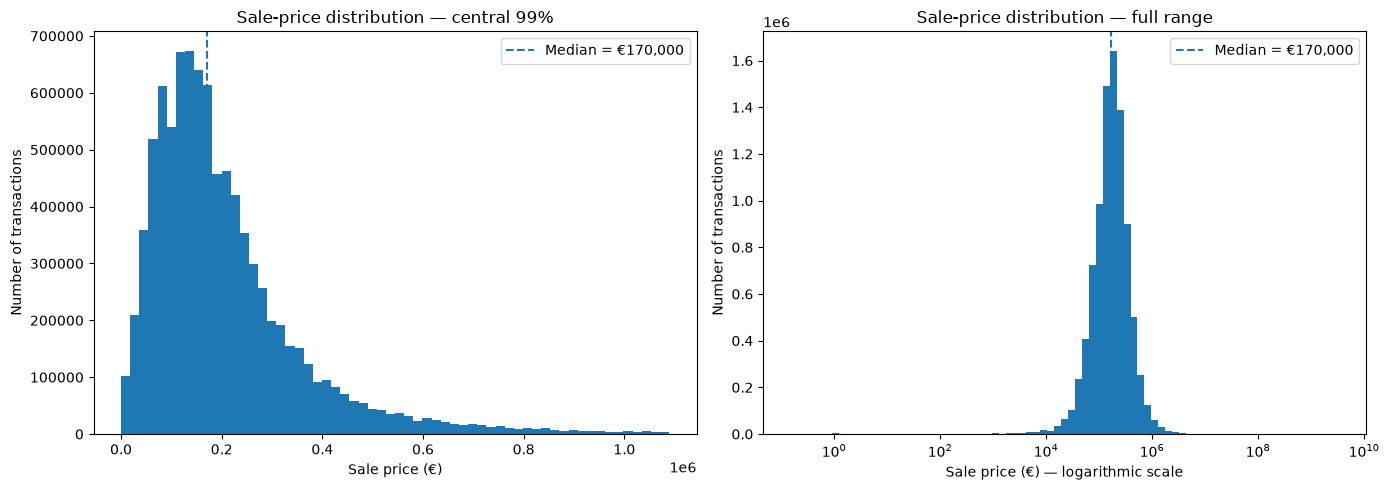

In [35]:
# Visualize the target distribution without hiding the extreme tail

positive_prices = price_eda.loc[
    price_eda["prix"] > 0,
    "prix"
]

p99_price = positive_prices.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Central 99% on the original euro scale
axes[0].hist(
    positive_prices[positive_prices <= p99_price],
    bins=60
)
axes[0].axvline(
    positive_prices.median(),
    linestyle="--",
    label=f"Median = €{positive_prices.median():,.0f}"
)
axes[0].set_title("Sale-price distribution — central 99%")
axes[0].set_xlabel("Sale price (€)")
axes[0].set_ylabel("Number of transactions")
axes[0].legend()

# Complete positive-price population on a logarithmic scale
axes[1].hist(
    positive_prices,
    bins=np.logspace(
        np.log10(positive_prices.min()),
        np.log10(positive_prices.max()),
        80
    )
)
axes[1].set_xscale("log")
axes[1].axvline(
    positive_prices.median(),
    linestyle="--",
    label=f"Median = €{positive_prices.median():,.0f}"
)
axes[1].set_title("Sale-price distribution — full range")
axes[1].set_xlabel("Sale price (€) — logarithmic scale")
axes[1].set_ylabel("Number of transactions")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation

The metropolitan sale-price distribution is strongly right-skewed.

Within the central 99% of positive-price transactions, most observations are concentrated in the lower hundreds of thousands of euros, while the frequency progressively decreases toward the upper end of the distribution. The median sale price is approximately €170,000, substantially below the mean of approximately €226,000, confirming the influence of the upper tail.

The full distribution on a logarithmic price scale shows that the bulk of transactions occupies a relatively concentrated range, while a very small number of observations extend across several additional orders of magnitude. Earlier record-level inspection showed that this tail contains both potentially legitimate high-value properties and observations whose price appears inconsistent with the associated dwelling characteristics.

Consequently, extreme prices should not be removed solely on the basis of a global percentile threshold. Target-quality rules will instead need to distinguish invalid or implausible observations from legitimate expensive properties.

The strong target skew also motivates testing modeling choices that are less sensitive to extreme errors. In later experiments, this includes using MAE as the primary evaluation metric and evaluating whether a logarithmic transformation of the target improves predictive behavior. No target transformation or price-based filtering is applied at this EDA stage.

## 7. Investigation of the lower price tail

The price distribution reveals a small number of zero or exceptionally low transaction prices.

Rather than applying an arbitrary minimum-price threshold, these observations are examined together with property characteristics and location. The objective is to determine whether very low prices represent plausible transactions, encoded missing values, data-quality problems, or transactions outside the intended residential valuation use case.

In [36]:
# Quantify the lower price tail

low_price_thresholds = pd.Series({
    "price_eq_0": (price_eda["prix"] == 0).sum(),
    "price_gt_0_le_100": (
        (price_eda["prix"] > 0) &
        (price_eda["prix"] <= 100)
    ).sum(),
    "price_gt_100_le_500": (
        (price_eda["prix"] > 100) &
        (price_eda["prix"] <= 500)
    ).sum(),
    "price_gt_500_le_1k": (
        (price_eda["prix"] > 500) &
        (price_eda["prix"] <= 1_000)
    ).sum(),
    "price_gt_1k_le_5k": (
        (price_eda["prix"] > 1_000) &
        (price_eda["prix"] <= 5_000)
    ).sum(),
    "price_gt_5k_le_10k": (
        (price_eda["prix"] > 5_000) &
        (price_eda["prix"] <= 10_000)
    ).sum(),
})

low_price_thresholds

price_eq_0               611
price_gt_0_le_100       5974
price_gt_100_le_500     3331
price_gt_500_le_1k      3561
price_gt_1k_le_5k      19434
price_gt_5k_le_10k     24084
dtype: int64

In [37]:
# Inspect very-low-price transactions with their property characteristics

low_price_records = (
    parquet_file
    .read(columns=[
        "id_transaction",
        "date_transaction",
        "prix",
        "departement",
        "ville",
        "code_postal",
        "type_batiment",
        "surface_habitable",
        "n_pieces",
        "vefa",
        "adresse",
    ])
    .to_pandas()
)

low_price_records = low_price_records.loc[
    (~low_price_records["departement"].isin(overseas_departments))
    & (low_price_records["prix"] <= 10_000)
].copy()

print(f"Metropolitan transactions <= €10,000: {len(low_price_records):,}")

low_price_records[
    [
        "prix",
        "date_transaction",
        "type_batiment",
        "surface_habitable",
        "n_pieces",
        "vefa",
        "ville",
        "departement",
        "adresse",
    ]
].sort_values("prix").head(30)

Metropolitan transactions <= €10,000: 56,995


,prix,date_transaction,type_batiment,surface_habitable,n_pieces,vefa,ville,departement,adresse
7099016,0.00,2014-11-07,Maison,177,6,False,ORGEVAL,78,302 RUE DU TREMBLAY
7098320,0.00,2014-10-21,Maison,135,5,False,SAINT-GERMAIN-EN-LAYE,78,32 RUE D ALSACE
4061015,0.00,2015-02-05,Maison,99,4,False,SAINT AVIT,47,33 FAURE
4061291,0.00,2015-03-06,Maison,92,4,False,LAFOX,47,104 BOUT DE L ILE
7979914,0.00,2014-02-26,Maison,91,5,False,LIMOGES,87,18 RUE LUCIEN FONTANAROSA
1523036,0.00,2014-04-01,Maison,120,4,False,PLOUGUENAST,22,5175 LAUNAY
4667863,0.00,2014-08-04,Maison,80,4,False,COULANGES LES NEVERS,58,11 IMP 1ERE IMP DES CHAUMOTTES
4668961,0.00,2015-01-30,Maison,86,4,False,IMPHY,58,9001 CHAMP DES JALONS
2129973,0.00,2014-06-19,Maison,324,8,False,AIGUES-VIVES,30,22 IMP DE LA BRASSERIE
4034159,0.00,2014-08-05,Maison,113,6,False,BALADOU,46,5028 BALADOU


In [38]:
# Create interpretable lower-price bands

low_price_records["price_band"] = pd.cut(
    low_price_records["prix"],
    bins=[-0.01, 0, 100, 500, 1_000, 5_000, 10_000],
    labels=[
        "€0",
        "€1–100",
        "€101–500",
        "€501–1,000",
        "€1,001–5,000",
        "€5,001–10,000",
    ],
    include_lowest=True,
)

low_price_records.groupby(
    ["price_band", "type_batiment"],
    observed=True
).agg(
    transactions=("prix", "size"),
    median_price=("prix", "median"),
    median_surface=("surface_habitable", "median"),
    median_rooms=("n_pieces", "median"),
)

transactions  median_price  median_surface  \
price_band    type_batiment                                               
€0            Appartement             235          0.00           60.00   
              Maison                  376          0.00           97.00   
€1–100        Appartement            2924          1.00           59.00   
              Maison                 3050          1.00           90.00   
€101–500      Appartement            1305        500.00           51.00   
              Maison                 2026        300.00           90.00   
€501–1,000    Appartement            1580      1,000.00           50.00   
              Maison                 1981      1,000.00           76.00   
€1,001–5,000  Appartement            7958      3,000.00           50.00   
              Maison                11476      3,500.00           57.00   
€5,001–10,000 Appartement            6313      8,000.00           47.00   
              Maison                17771      9,000.00           55.00   

                             median_rooms  
price_band    type_batiment                
€0            Appartement            3.00  
              Maison                 4.00  
€1–100        Appartement            3.00  
              Maison                 4.00  
€101–500      Appartement            2.00  
              Maison                 4.00  
€501–1,000    Appartement            2.00  
              Maison                 3.00  
€1,001–5,000  Appartement            2.00  
              Maison                 2.00  
€5,001–10,000 Appartement            2.00  
              Maison                 2.00

In [39]:
low_price_examples = (
    low_price_records
    .groupby("price_band", observed=True, group_keys=False)
    .sample(n=5, random_state=RANDOM_STATE)
    .sort_values(["price_band", "prix"])
)

low_price_examples[
    [
        "price_band",
        "prix",
        "date_transaction",
        "type_batiment",
        "surface_habitable",
        "n_pieces",
        "vefa",
        "ville",
        "departement",
        "adresse",
    ]
]

,price_band,prix,date_transaction,type_batiment,surface_habitable,n_pieces,vefa,ville,departement,adresse
1162170,€0,0.00,2015-06-03,Appartement,108,6,False,AURILLAC,15,12 RUE RAYMOND CORTAT
3253480,€0,0.00,2014-04-05,Maison,127,5,False,DIZIMIEU,38,36 MTE DU PIN
649083,€0,0.00,2014-12-17,Appartement,92,5,False,NARBONNE,11,16 RUE MARYSE BASTIE
8725054,€0,0.00,2015-01-29,Maison,114,5,False,VILLENEUVE-SAINT-GEORGES,94,11 RUE CHARLES CHAPLIN
4221978,€0,0.00,2015-03-13,Maison,74,3,False,NEHOU,50,41D RUE DU BOURG
8857433,€1–100,1.00,2022-04-20,Appartement,152,6,False,SAINT-MAUR-DES-FOSSES,94,1 AV MEDICIS
338148,€1–100,1.00,2017-12-14,Maison,120,7,False,ANTIBES,06,17 BD MARECHAL FOCH
2221654,€1–100,1.00,2023-03-08,Maison,100,4,False,MOULEZAN,30,5107 CHE DE CANTEPERDRIX
4950507,€1–100,2.00,2021-09-15,Appartement,60,2,False,CROIX,59,7 RUE DU PROFESSEUR PERRIN
6580079,€1–100,100.00,2020-02-27,Appartement,134,4,False,PARIS 16,75,94 AV HENRI MARTIN


### Price-to-property consistency

Absolute price alone is insufficient for identifying questionable transactions because legitimate market values vary substantially with property size and location.

As a diagnostic, sale price per square metre is therefore examined for records with strictly positive price and habitable surface. This ratio is not yet used as a filtering rule or predictive feature. Its purpose here is to identify observations whose recorded price is internally inconsistent with the associated residential surface.

In [40]:
# Price per m² diagnostic on the metropolitan population

price_surface_eda = (
    parquet_file
    .read(columns=[
        "prix",
        "surface_habitable",
        "departement",
        "type_batiment",
    ])
    .to_pandas()
)

price_surface_eda = price_surface_eda.loc[
    (~price_surface_eda["departement"].isin(overseas_departments))
    & (price_surface_eda["prix"] > 0)
    & (price_surface_eda["surface_habitable"] > 0)
].copy()

price_surface_eda["price_per_m2"] = (
    price_surface_eda["prix"]
    / price_surface_eda["surface_habitable"]
)

price_per_m2_quantiles = (
    price_surface_eda["price_per_m2"]
    .quantile([
        0.0001,
        0.001,
        0.005,
        0.01,
        0.05,
        0.50,
        0.95,
        0.99,
        0.995,
        0.999,
        0.9999,
    ])
    .rename("price_per_m2")
    .to_frame()
)

price_per_m2_quantiles

,price_per_m2
0.00,0.01
0.00,7.69
0.01,136.59
0.01,250.00
0.05,657.89
0.50,"2,327.27"
0.95,"7,605.63"
0.99,"12,240.00"
0.99,"14,367.82"
1.00,"25,263.16"


In [41]:
pd.Series({
    "below_1_eur_m2":
        (price_surface_eda["price_per_m2"] < 1).sum(),

    "below_10_eur_m2":
        (price_surface_eda["price_per_m2"] < 10).sum(),

    "below_100_eur_m2":
        (price_surface_eda["price_per_m2"] < 100).sum(),

    "above_20k_eur_m2":
        (price_surface_eda["price_per_m2"] > 20_000).sum(),

    "above_50k_eur_m2":
        (price_surface_eda["price_per_m2"] > 50_000).sum(),

    "above_100k_eur_m2":
        (price_surface_eda["price_per_m2"] > 100_000).sum(),
})

below_1_eur_m2        5440
below_10_eur_m2       9869
below_100_eur_m2     33858
above_20k_eur_m2     15398
above_50k_eur_m2      2977
above_100k_eur_m2     1231
dtype: int64

### Temporal distribution of price-per-m² anomalies

Extreme price-per-m² observations are examined over time to determine whether they are concentrated in a particular data period or persist throughout the transaction history.

This analysis remains diagnostic: the thresholds below identify records for investigation and are not yet exclusion rules.

In [42]:
# Temporal distribution of extreme price-per-m² observations

price_surface_eda["year"] = (
    pd.to_datetime(
        parquet_file
        .read(columns=["date_transaction"])
        .to_pandas()["date_transaction"]
    )
    .dt.year
)

yearly_price_quality = (
    price_surface_eda
    .groupby("year")
    .agg(
        transactions=("price_per_m2", "size"),
        below_10_m2=("price_per_m2", lambda x: (x < 10).sum()),
        below_100_m2=("price_per_m2", lambda x: (x < 100).sum()),
        above_50k_m2=("price_per_m2", lambda x: (x > 50_000).sum()),
        above_100k_m2=("price_per_m2", lambda x: (x > 100_000).sum()),
    )
)

yearly_price_quality["below_100_pct"] = (
    100 * yearly_price_quality["below_100_m2"]
    / yearly_price_quality["transactions"]
)

yearly_price_quality["above_50k_pct"] = (
    100 * yearly_price_quality["above_50k_m2"]
    / yearly_price_quality["transactions"]
)

yearly_price_quality

,transactions,below_10_m2,below_100_m2,above_50k_m2,above_100k_m2,below_100_pct,above_50k_pct
year,,,,,,,
2014,635268,979,2959,170,70,0.47,0.03
2015,724715,875,2841,172,73,0.39,0.02
2016,776310,776,2814,191,79,0.36,0.02
2017,895941,817,2955,248,101,0.33,0.03
2018,891784,1022,3518,283,107,0.39,0.03
2019,969692,1091,3794,376,158,0.39,0.04
2020,935414,869,3184,284,128,0.34,0.03
2021,1080434,992,3718,312,127,0.34,0.03
2022,1022966,1059,3447,449,193,0.34,0.04


In [43]:
# Rebuild the diagnostic table with dates included from the start

price_surface_time = (
    parquet_file
    .read(columns=[
        "date_transaction",
        "prix",
        "surface_habitable",
        "departement",
    ])
    .to_pandas()
)

price_surface_time = price_surface_time.loc[
    (~price_surface_time["departement"].isin(overseas_departments))
    & (price_surface_time["prix"] > 0)
    & (price_surface_time["surface_habitable"] > 0)
].copy()

price_surface_time["price_per_m2"] = (
    price_surface_time["prix"]
    / price_surface_time["surface_habitable"]
)

price_surface_time["year"] = (
    price_surface_time["date_transaction"].dt.year
)

yearly_price_quality = (
    price_surface_time
    .groupby("year")
    .agg(
        transactions=("price_per_m2", "size"),
        below_10_m2=("price_per_m2", lambda x: (x < 10).sum()),
        below_100_m2=("price_per_m2", lambda x: (x < 100).sum()),
        above_50k_m2=("price_per_m2", lambda x: (x > 50_000).sum()),
        above_100k_m2=("price_per_m2", lambda x: (x > 100_000).sum()),
    )
)

yearly_price_quality["below_100_pct"] = (
    100
    * yearly_price_quality["below_100_m2"]
    / yearly_price_quality["transactions"]
)

yearly_price_quality["above_50k_pct"] = (
    100
    * yearly_price_quality["above_50k_m2"]
    / yearly_price_quality["transactions"]
)

yearly_price_quality

,transactions,below_10_m2,below_100_m2,above_50k_m2,above_100k_m2,below_100_pct,above_50k_pct
year,,,,,,,
2014,635268,979,2959,170,70,0.47,0.03
2015,724715,875,2841,172,73,0.39,0.02
2016,776310,776,2814,191,79,0.36,0.02
2017,895941,817,2955,248,101,0.33,0.03
2018,891784,1022,3518,283,107,0.39,0.03
2019,969692,1091,3794,376,158,0.39,0.04
2020,935414,869,3184,284,128,0.34,0.03
2021,1080434,992,3718,312,127,0.34,0.03
2022,1022966,1059,3447,449,193,0.34,0.04


### Interpretation

Extreme price-per-m² observations are not confined to a particular acquisition period. Transactions below €100/m² occur in every observed year, representing approximately 0.33%–0.47% of otherwise eligible metropolitan transactions. Extremely high ratios above €50,000/m² are substantially rarer but likewise persist throughout the dataset.

The temporal stability of these tails suggests a recurring transaction- or record-level phenomenon rather than an isolated problem affecting a single year of data. Consequently, excluding an entire historical period would not address the issue.

These thresholds remain diagnostic rather than filtering rules. Because residential values vary substantially by location and property characteristics, national price-per-m² cutoffs alone are insufficient to determine whether an individual transaction is invalid.

## 8. Provisional data-cleaning policy

The audit and focused EDA identify a small number of issues that must be addressed before modeling. Cleaning decisions are intentionally conservative: observations are excluded only when they are incompatible with the intended prediction task or clearly unusable, rather than through arbitrary percentile trimming.

| Issue | Provisional treatment | Rationale |
|---|---|---|
| Overseas departments (971–974) | Exclude | Product scope is metropolitan France |
| `prix == 0` | Exclude | Zero is not a meaningful residential sale-value target; inspected records otherwise describe ordinary properties |
| `surface_habitable == 0` | Exclude | Habitable surface is essential to the valuation task and zero is not meaningful for the observed residential records |
| `n_pieces == 0` | Retain but treat as missing/unknown | Zero appears to encode unavailable information rather than a literal zero-room dwelling |
| Very large `n_pieces` | Validate / constrain before modeling | A small pathological tail contains internally inconsistent values |
| Very large `surface_habitable` | Validate / constrain before modeling | Record inspection identified implausible building-level or propagated surface values |
| Extreme `prix` or price/m² | Do not remove solely by national percentile | The tails contain both suspicious observations and potentially legitimate expensive properties |
| Exact address | Exclude from initial predictors | High cardinality, privacy/generalization concerns, and risk of memorization |
| Cadastral parcel ID | Exclude from initial predictors | Identifier-like, high-cardinality feature with memorization/generalization risk |
| Transaction ID | Exclude from predictors | Identifier rather than explanatory property information |
| Overseas coordinates | Removed through geographic scope | No independent coordinate filter required |
| Encoded `{}` surface fields | Transform/evaluate later | Empty containers represent semantic absence rather than standard nulls |

In [44]:
# Aanalize structural problems—rooms and surface

structural_tail = (
    parquet_file
    .read(columns=[
        "surface_habitable",
        "n_pieces",
        "type_batiment",
        "departement",
    ])
    .to_pandas()
)

structural_tail = structural_tail.loc[
    ~structural_tail["departement"].isin(overseas_departments)
]

pd.DataFrame({
    "surface_gt_300": [(structural_tail["surface_habitable"] > 300).sum()],
    "surface_gt_500": [(structural_tail["surface_habitable"] > 500).sum()],
    "surface_gt_1000": [(structural_tail["surface_habitable"] > 1000).sum()],
    "rooms_gt_10": [(structural_tail["n_pieces"] > 10).sum()],
    "rooms_gt_15": [(structural_tail["n_pieces"] > 15).sum()],
    "rooms_gt_20": [(structural_tail["n_pieces"] > 20).sum()],
})

,surface_gt_300,surface_gt_500,surface_gt_1000,rooms_gt_10,rooms_gt_15,rooms_gt_20
0,19561,1514,99,9379,1081,577


### Structural-variable decision

Extreme structural values affect only a very small fraction of the metropolitan dataset. Previous record-level inspection nevertheless identified clear inconsistencies in the most extreme tail, including implausibly large habitable surfaces and room counts relative to dwelling size.

At this stage, no broad percentile-based row deletion is applied. Zero habitable surface is excluded because it is incompatible with the intended residential valuation task, while zero rooms is interpreted as unavailable information rather than a literal value and will be converted to missing.

Extreme positive surface and room-count values are retained initially and monitored during baseline modeling. More restrictive treatment will only be introduced if validation results or model diagnostics demonstrate a material benefit. This conservative strategy avoids deleting legitimate large or atypical properties solely because they are rare.

# Modeling Dataset

## 9. Construction of the modeling population

The modeling population is constructed from the raw transaction dataset using only cleaning decisions supported by the preceding audit and EDA.

At this stage, cleaning is deliberately conservative. The objective is to remove observations that are incompatible with the intended prediction task while avoiding arbitrary trimming of rare but potentially legitimate properties.

Confirmed row-level exclusions are:

- transactions outside metropolitan France;
- transactions with a zero sale price;
- transactions with zero habitable surface.

A zero value for `n_pieces` is not treated as a row-level exclusion because the audit suggests that it represents unavailable information rather than a literal zero-room dwelling. It will be converted to a missing value during feature preparation.

Extreme positive prices, surfaces, and room counts are retained at this stage and will be monitored through model validation and error analysis.

In [46]:
# PURPOSE:
# Build the initial modeling population using only confirmed cleaning rules.
# The audit table records how many rows are removed at each step so that
# preprocessing remains transparent and reproducible.

model_df = parquet_file.read().to_pandas()

cleaning_audit = []

# Starting population
cleaning_audit.append({
    "step": "Raw transactions",
    "rows": len(model_df),
})

# 1. Restrict the product to metropolitan France
model_df = model_df.loc[
    ~model_df["departement"].isin(overseas_departments)
].copy()

cleaning_audit.append({
    "step": "Metropolitan France",
    "rows": len(model_df),
})

# 2. Remove transactions without a usable sale-price target
model_df = model_df.loc[
    model_df["prix"] > 0
].copy()

cleaning_audit.append({
    "step": "Positive sale price",
    "rows": len(model_df),
})

# 3. Remove transactions without a usable habitable surface
model_df = model_df.loc[
    model_df["surface_habitable"] > 0
].copy()

cleaning_audit.append({
    "step": "Positive habitable surface",
    "rows": len(model_df),
})

# Convert zero room counts to missing values rather than deleting the rows
model_df["n_pieces"] = (
    model_df["n_pieces"]
    .replace(0, np.nan)
)

# Convert the audit results into a readable table
cleaning_audit = pd.DataFrame(cleaning_audit)

cleaning_audit["rows_removed"] = (
    cleaning_audit["rows"]
    .shift(1)
    .sub(cleaning_audit["rows"])
)

cleaning_audit["rows_removed_pct"] = (
    100
    * cleaning_audit["rows_removed"]
    / cleaning_audit["rows"].shift(1)
)

cleaning_audit

,step,rows,rows_removed,rows_removed_pct
0,Raw transactions,9141573,NaN,NaN
1,Metropolitan France,9046165,"95,408.00",1.04
2,Positive sale price,9045554,611.00,0.01
3,Positive habitable surface,9045548,6.00,0.00


### Cleaning impact

The initial modeling population contains **9,045,548 transactions**, retaining approximately **98.95% of the raw dataset**.

Most excluded observations (95,408 rows) correspond to overseas departments and are removed because the product is explicitly scoped to metropolitan France rather than because of data quality.

Only 617 additional records are removed through confirmed quality rules: 611 transactions have a zero sale price and 6 have zero habitable surface.

The resulting dataset therefore preserves virtually all metropolitan transactions. No broad percentile-based removal of expensive, inexpensive, large, or otherwise unusual properties has been applied.

## Figures

In [45]:
# Save a presentation-quality version of the figure
plt.savefig(
    PROJECT_ROOT / "outputs" / "figures" / "price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## 10. Presentation-ready EDA figures

### Transaction volume over time

Annual transaction counts provide a concise view of the dataset's temporal coverage. The final year, 2024, contains observations only through June and must therefore be interpreted as a partial year.

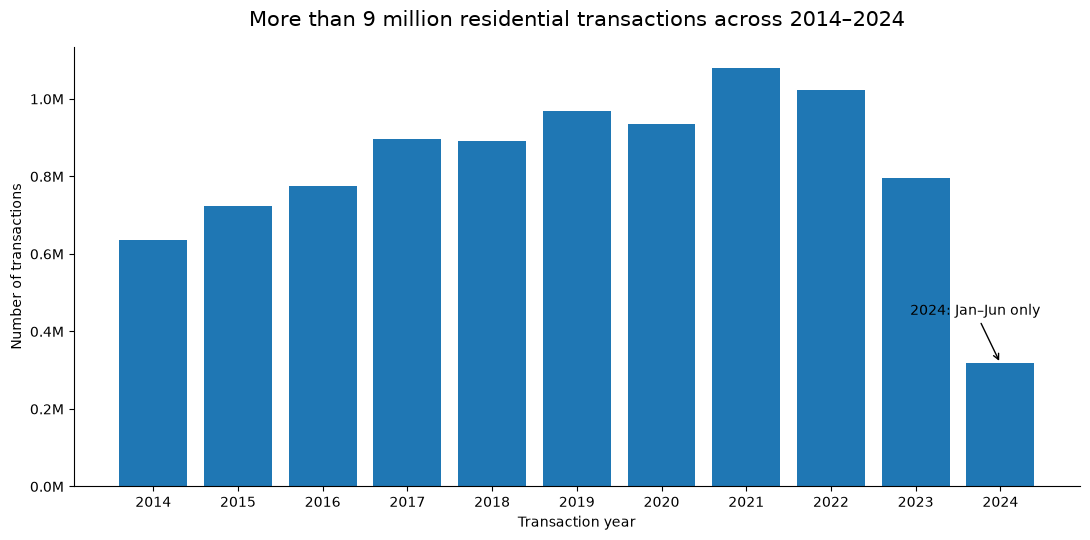

Figure saved to: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\outputs\figures\transactions_by_year.png


In [47]:
# PURPOSE:
# Visualize the temporal coverage and scale of the modeling dataset.
# This figure is designed for both the EDA notebook and final presentation.
# Note: 2024 contains data only through June and is therefore a partial year.

transactions_by_year = (
    model_df
    .assign(year=model_df["date_transaction"].dt.year)
    .groupby("year")
    .size()
)

fig, ax = plt.subplots(figsize=(11, 5.5))

bars = ax.bar(
    transactions_by_year.index.astype(str),
    transactions_by_year.values
)

ax.set_title(
    "More than 9 million residential transactions across 2014–2024",
    fontsize=15,
    pad=15
)
ax.set_xlabel("Transaction year")
ax.set_ylabel("Number of transactions")

# Make the y-axis easier to read in millions
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x / 1_000_000:.1f}M")
)

# Explicitly identify 2024 as an incomplete observation year
ax.annotate(
    "2024: Jan–Jun only",
    xy=(len(transactions_by_year) - 1, transactions_by_year.iloc[-1]),
    xytext=(-65, 35),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"},
    fontsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save a high-resolution version for the final presentation
figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "transactions_by_year.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

### Evolution of median price per square metre

Median sale price per square metre is tracked over time for houses and apartments. This provides a more comparable measure of market evolution than total transaction price because it accounts for differences in property size.

The median is used rather than the mean to reduce sensitivity to the extreme price tail identified earlier.

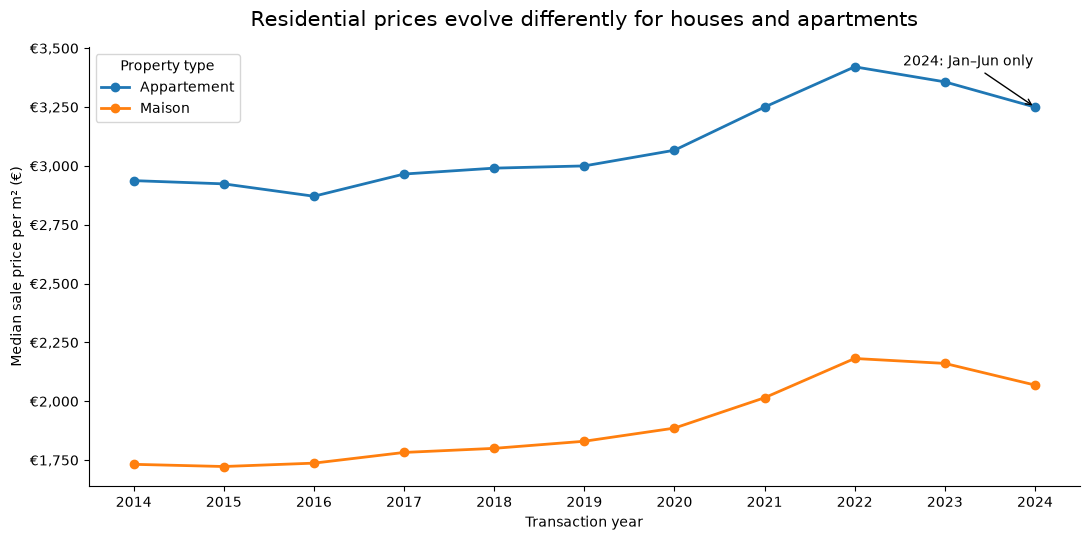

Figure saved to: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\outputs\figures\median_price_per_m2_by_year_and_type.png


In [48]:
# PURPOSE:
# Show how the residential market evolves over time and compare houses
# with apartments using median sale price per square metre.
#
# This helps justify:
# 1. using transaction date as predictive information;
# 2. retaining property type as an important feature;
# 3. using temporal rather than purely random model validation.
#
# The figure is also saved at high resolution for the final presentation.

market_evolution = model_df.loc[
    model_df["surface_habitable"] > 0
].copy()

market_evolution["year"] = (
    market_evolution["date_transaction"].dt.year
)

market_evolution["price_per_m2"] = (
    market_evolution["prix"]
    / market_evolution["surface_habitable"]
)

yearly_market = (
    market_evolution
    .groupby(["year", "type_batiment"])["price_per_m2"]
    .median()
    .unstack()
)

fig, ax = plt.subplots(figsize=(11, 5.5))

for property_type in yearly_market.columns:
    ax.plot(
        yearly_market.index,
        yearly_market[property_type],
        marker="o",
        linewidth=2,
        label=property_type
    )

ax.set_title(
    "Residential prices evolve differently for houses and apartments",
    fontsize=15,
    pad=15
)
ax.set_xlabel("Transaction year")
ax.set_ylabel("Median sale price per m² (€)")

ax.set_xticks(yearly_market.index)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x:,.0f}")
)

ax.legend(title="Property type")

# Remind the reader that the final year is incomplete
ax.annotate(
    "2024: Jan–Jun only",
    xy=(
        yearly_market.index[-1],
        yearly_market.iloc[-1].max()
    ),
    xytext=(-95, 30),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"},
    fontsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save a presentation-quality copy
figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "median_price_per_m2_by_year_and_type.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

### Interpretation

Median sale price per square metre differs substantially between houses and apartments throughout the observation period, confirming that property type contains important valuation information.

Both property types also exhibit meaningful temporal variation. Median price per m² generally increases through the later years of the dataset before declining after 2022. The 2024 values cover January through June only and should therefore be interpreted as a partial-year observation.

These patterns support retaining both property type and transaction time as predictive information. They also reinforce the use of temporal validation: a model intended to estimate future transactions should be evaluated on transactions occurring after those used for training.

### Geographic variation in residential prices

Real-estate valuation is strongly location-dependent. To visualize this spatial structure, transactions are aggregated at city level and represented using their median geographic coordinates and median sale price per square metre.

City-level aggregation reduces transaction-level noise and makes broad spatial differences across metropolitan France visible without using exact property addresses.

In [49]:
# PURPOSE:
# Measure geographic variation in residential property values.
#
# Transactions are aggregated by city so that the visualization shows
# local market structure rather than millions of individual sales.
#
# This helps justify geographic features such as latitude, longitude,
# department and city-level information in the predictive model.

geo_eda = model_df.loc[
    (model_df["surface_habitable"] > 0)
].copy()

# Calculate transaction-level price per m² for geographic aggregation
geo_eda["price_per_m2"] = (
    geo_eda["prix"]
    / geo_eda["surface_habitable"]
)

# Aggregate transactions at city level
city_market = (
    geo_eda
    .groupby(["id_ville", "ville", "departement"])
    .agg(
        transactions=("prix", "size"),
        latitude=("latitude", "median"),
        longitude=("longitude", "median"),
        median_price_per_m2=("price_per_m2", "median"),
    )
    .reset_index()
)

# Require enough observations for a more stable city-level estimate
city_market_plot = city_market.loc[
    city_market["transactions"] >= 30
].copy()

print(f"Cities in geographic analysis: {len(city_market):,}")
print(f"Cities plotted (>=30 transactions): {len(city_market_plot):,}")

city_market_plot[
    ["transactions", "median_price_per_m2"]
].describe()

Cities in geographic analysis: 34,483
Cities plotted (>=30 transactions): 23,762


,transactions,median_price_per_m2
count,"23,762.00","23,762.00"
mean,373.44,"1,673.19"
std,"1,739.86",834.73
min,30.00,250.00
25%,52.00,"1,150.40"
50%,94.00,"1,500.00"
75%,214.00,"1,966.15"
max,"96,001.00","13,400.00"


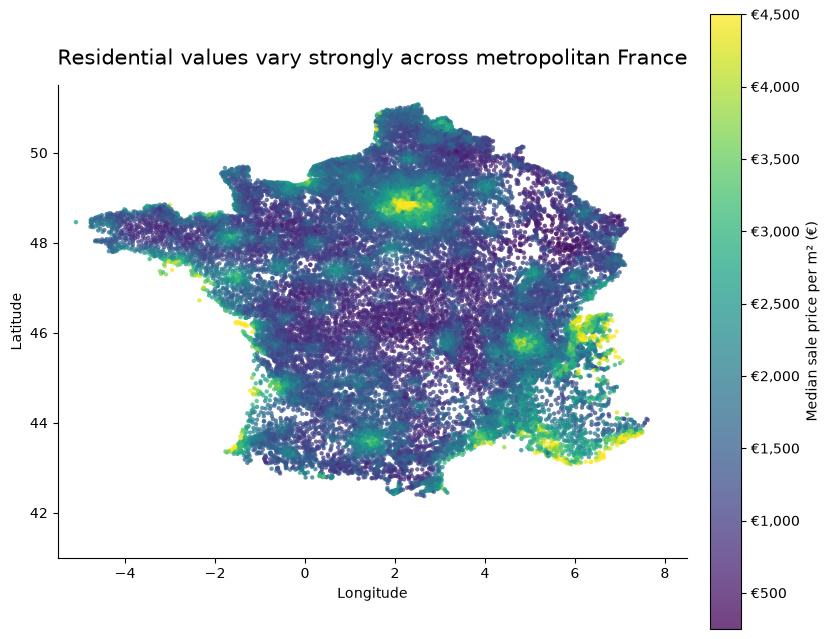

99th percentile used as visual color cap: €4,502/m²
Figure saved to: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\outputs\figures\geographic_median_price_per_m2.png


In [50]:
# PURPOSE:
# Create a presentation-ready geographic view of residential values
# across metropolitan France.
#
# Each point represents a city with at least 30 observed transactions.
# Color represents the city's median sale price per m².
#
# The color scale is capped at the 99th percentile FOR VISUALIZATION ONLY,
# so a small number of very expensive cities do not hide geographic
# differences across the rest of France. No observations are removed
# from the modeling dataset.

geo_color_max = city_market_plot["median_price_per_m2"].quantile(0.99)

fig, ax = plt.subplots(figsize=(8.5, 8.5))

scatter = ax.scatter(
    city_market_plot["longitude"],
    city_market_plot["latitude"],
    c=city_market_plot["median_price_per_m2"],
    s=10,
    alpha=0.75,
    cmap="viridis",
    vmin=city_market_plot["median_price_per_m2"].min(),
    vmax=geo_color_max,
    linewidths=0
)

ax.set_title(
    "Residential values vary strongly across metropolitan France",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Keep the map focused on metropolitan France
ax.set_xlim(-5.5, 8.5)
ax.set_ylim(41.0, 51.5)

# Preserve approximately correct geographic proportions
ax.set_aspect("equal", adjustable="box")

colorbar = plt.colorbar(
    scatter,
    ax=ax,
    shrink=0.75,
    pad=0.03
)

colorbar.set_label("Median sale price per m² (€)")

colorbar.ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x:,.0f}")
)

# Remove unnecessary chart borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save a high-resolution version for the final presentation
figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "geographic_median_price_per_m2.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"99th percentile used as visual color cap: €{geo_color_max:,.0f}/m²")
print(f"Figure saved to: {figure_path}")

### Interpretation

Residential values exhibit strong spatial heterogeneity across metropolitan France. City-level median price per square metre varies substantially across the territory, with visible concentrations of higher-value markets alongside broad lower-priced areas.

This spatial structure confirms that geographic information is essential to the valuation problem. Latitude and longitude should therefore be retained as candidate predictors, while administrative or city-level geographic information may provide additional local-market signal.

The visualization uses cities with at least 30 observed transactions to obtain more stable descriptive estimates. The upper end of the color scale is capped at the 99th percentile for visualization only; this does not remove observations from the modeling dataset.

### Relationship between property size and sale price

Habitable surface is expected to be one of the principal determinants of total property value. To visualize this relationship without allowing millions of overlapping observations or extreme prices to dominate the figure, properties are grouped into surface intervals and their median sale prices are compared separately for houses and apartments.

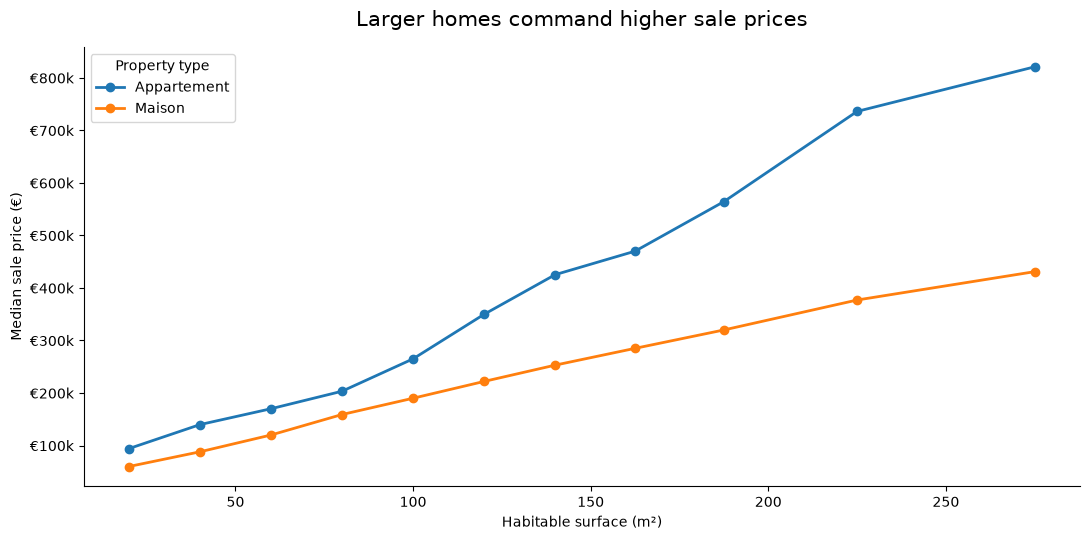

Figure saved to: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\6_french-property-intelligence\outputs\figures\median_price_by_surface_and_type.png


In [51]:
# PURPOSE:
# Show the relationship between habitable surface and total sale price,
# separately for houses and apartments.
#
# Median prices within surface bands provide a robust and readable view
# of the relationship without plotting millions of individual transactions.
#
# This figure helps justify retaining surface_habitable and type_batiment
# as core predictive features and is saved for the final presentation.

surface_plot = model_df.loc[
    (model_df["surface_habitable"] >= 10)
    & (model_df["surface_habitable"] <= 300)
].copy()

# Use interpretable residential surface bands.
# These limits are used FOR VISUALIZATION ONLY and are not cleaning rules.
surface_bins = [
    10, 30, 50, 70, 90, 110,
    130, 150, 175, 200, 250, 300
]

surface_plot["surface_band"] = pd.cut(
    surface_plot["surface_habitable"],
    bins=surface_bins,
    include_lowest=True
)

surface_price_summary = (
    surface_plot
    .groupby(
        ["surface_band", "type_batiment"],
        observed=True
    )
    .agg(
        median_price=("prix", "median"),
        transactions=("prix", "size"),
    )
    .reset_index()
)

# Use the midpoint of each surface interval for the x-axis
surface_price_summary["surface_midpoint"] = (
    surface_price_summary["surface_band"]
    .apply(lambda interval: interval.mid)
    .astype(float)
)

fig, ax = plt.subplots(figsize=(11, 5.5))

for property_type in ["Appartement", "Maison"]:
    subset = surface_price_summary.loc[
        surface_price_summary["type_batiment"] == property_type
    ]

    ax.plot(
        subset["surface_midpoint"],
        subset["median_price"],
        marker="o",
        linewidth=2,
        label=property_type
    )

ax.set_title(
    "Larger homes command higher sale prices",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Habitable surface (m²)")
ax.set_ylabel("Median sale price (€)")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x / 1_000:.0f}k")
)

ax.legend(title="Property type")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save a high-resolution version for the final presentation
figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "median_price_by_surface_and_type.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

### Interpretation

Median sale price increases strongly with habitable surface for both houses and apartments, confirming surface as a core predictor of residential value.

The relationship also differs substantially by property type. For comparable surface ranges, apartments exhibit higher median transaction prices than houses in the national dataset, and the gap becomes more pronounced among larger properties.

This indicates that property characteristics should not be interpreted independently: the effect of habitable surface interacts with property type and location. Flexible nonlinear models will therefore be evaluated alongside linear baselines.

The 10–300 m² range used in this figure is a visualization choice only and does not constitute a modeling-data exclusion rule.